# ***CNN (Convolutional Neural Network)***

In [ ]:
import tensorflow as tf

print("Available devices:", tf.config.list_physical_devices())
print("GPU is available:", tf.test.is_gpu_available())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Доступные устройства: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU доступен: True


## Step 0: Setting the random_seed
 - Goal: to fix the random seed for Python, NumPy and TensorFlow so that the results remain as consistent as possible when the training is run again

In [ ]:
import tensorflow as tf
import numpy as np
import random
import os

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Stage 1: Data preparation and loading

## Step 1: Checking the data structure

In [ ]:
# banana_dataset/
#     dataset/
#         train/
#             unripe/
#             ripe/
#             overripe/
#         val/
#             unripe/
#             ripe/
#             overripe/
#         test/
#             unripe/
#             ripe/
#             overripe/

## Step 2: Project settings

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = 3

## Step 3: Loading the data (train, val, test)

In [ ]:
# 3.1 Connecting to Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 3.2 Checking the path to the folders

!ls "/content/drive/MyDrive/banana_dataset"

dataset


In [ ]:
# 3.3 Checking the contents

!ls "/content/drive/MyDrive/banana_dataset/dataset"

test  train  val


In [ ]:
!ls "/content/drive/MyDrive/banana_dataset/dataset/train"

overripe  ripe	unripe


In [ ]:
!ls "/content/drive/MyDrive/banana_dataset/dataset/val"

overripe  ripe	unripe


In [ ]:
# 3.4 Loading data using Keras:

# Goal:
# read images
# automatically resize them
# identify the class to which each image belongs
# split the data into train/val/test sets
# create batches

import tensorflow as tf #

train_dir = "/content/drive/MyDrive/banana_dataset/dataset/train"
val_dir = "/content/drive/MyDrive/banana_dataset/dataset/val"
test_dir = "/content/drive/MyDrive/banana_dataset/dataset/test"

print("------------------ TRAIN: ------------------")
train_ds = tf.keras.preprocessing.image_dataset_from_directory( #creates an image dataset from folders
    train_dir,                       # path to the train folder
    seed=seed,
    image_size=(IMG_HEIGHT, IMG_WIDTH), # resizes each image to 224px
    batch_size=BATCH_SIZE,              # collects 32 images at a time
    label_mode='categorical'
    # 'categorical' -> means we have several classes, and the labels will be in the form of one-hot encoding, ex: unripe - [1, 0, 0], ripe - [0, 1, 0], overripe - [0, 0, 1],
)

print("------------------ VALIDATION: ------------------")
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

print("----------------- TEST: ------------------")
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# shuffle=False : helps to
# Know exactly which banana the model failed to recognise.
# Obtain the same results every time the test is run.
# Construct a correct confusion matrix.

------------------ TRAIN: ------------------
Found 6734 files belonging to 3 classes.
------------------ VALIDATION: ------------------
Found 1825 files belonging to 3 classes.
----------------- TEST: ------------------
Found 1401 files belonging to 3 classes.


In [ ]:
class_names = train_ds.class_names
print(class_names)

print("Order of classes: ")
for i, name in enumerate(class_names):
    print(f"{i} -> {name}")

['overripe', 'ripe', 'unripe']
Order of classes: 
0 -> overripe
1 -> ripe
2 -> unripe


In [ ]:
# 3.5 Checking the number of images by category

# Goal:
# ensure that the data is distributed correctly
# check for any imbalance
# determine how many examples there are in each class
# assess whether there is enough data for training

import os     #library for working with folders and files

def count_images(directory):     # function to count the number of images in each class folder
    counts = {}                  # store the result as a dictionary: {'unripe': 620, ...}

    for class_name in os.listdir(directory):               # iterate through each item in the folder (unripe, ripe, overripe)
        class_path = os.path.join(directory, class_name)   # create the full path to the class folder

        if os.path.isdir(class_path):                # checking that this is actually a folder and not a file
            counts[class_name] = len(os.listdir(class_path))    # counting the number of files (images) in the class folder

    return counts       # return a dictionary containing the number of images

print("TRAIN SET:", count_images(train_dir))

print("VALIDATION SET:", count_images(val_dir))
print("TEST SET:", count_images(test_dir))

TRAIN SET: {'overripe': 4299, 'ripe': 1815, 'unripe': 620}
VALIDATION SET: {'unripe': 184, 'overripe': 1326, 'ripe': 315}
TEST SET: {'overripe': 1010, 'ripe': 211, 'unripe': 180}


In [ ]:
# 3.5 Table visualisation

import pandas as pd   # a library for tables

train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

df = pd.DataFrame({
    "Class": ["overripe", "ripe", "unripe"],
    "Train count": [train_counts.get("overripe", 0),
                    train_counts.get("ripe", 0),
                    train_counts.get("unripe", 0)],
    "Validation Count": [val_counts.get("overripe", 0),
                         val_counts.get("ripe", 0),
                         val_counts.get("unripe", 0)],
    "Test Count": [test_counts.get("overripe", 0),
                   test_counts.get("ripe", 0),
                   test_counts.get("unripe", 0)]
})

df

,Class,Train count,Validation Count,Test Count
0,overripe,4299,1326,1010
1,ripe,1815,315,211
2,unripe,620,184,180


In [ ]:
# 3.6 DATA AUGMENTATION

# This is important because my dataset is UNBALANCED: the ‘overripe’ class is much larger

# Augmentation will help:
# increase the number of unripe and ripe samples
# improve generalisation
# reduce overfitting
# make the model robust to different angles, lighting and noise

# without augmentation, the CNN will perform less effectively

from tensorflow.keras import layers    # to create an augmentation layer

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),  # random reflection
    layers.RandomRotation(0.1),       # small turn to 10%
    layers.RandomZoom(0.1),           # small increase
    layers.RandomBrightness(0.2),     # changing brightness(resistance to light)
    layers.RandomContrast(0.2),       # changing the contrast(resistance to camera quality)
])

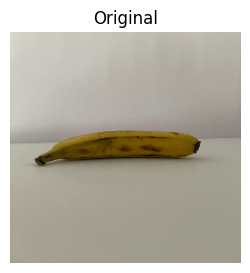

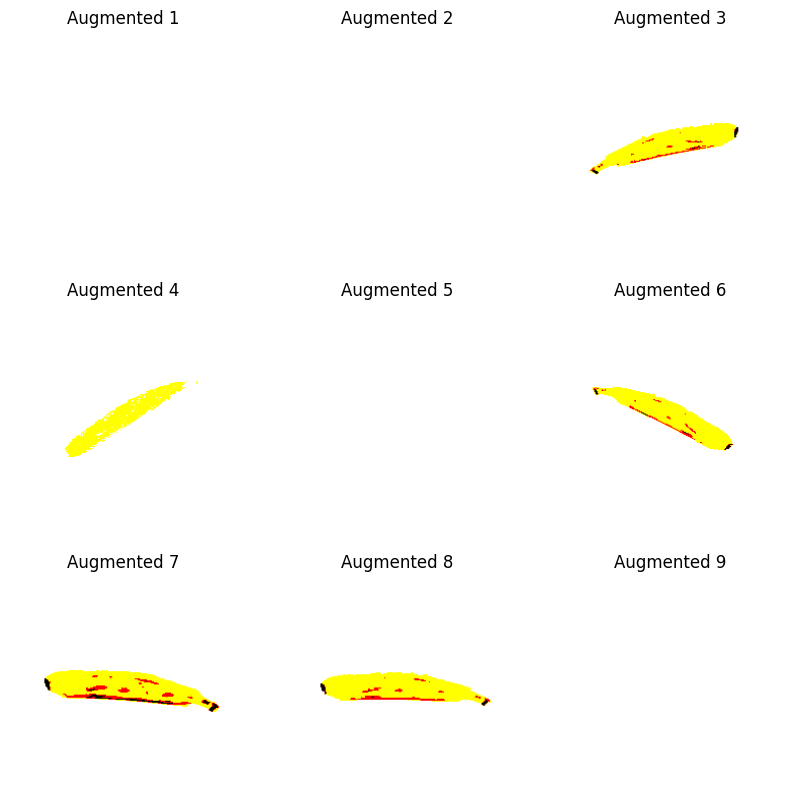

In [ ]:
# 3.7 Visualisation of augmentation

import matplotlib.pyplot as plt
import numpy as np

# take a single batch of images from train_ds
for images, labels in train_ds.take(1):
    original_image = images[15].numpy().astype("uint8")  # берём изображение
    break

# function for displaying images
def show_image(img):
    plt.imshow(img)
    plt.axis('off')

# the original
plt.figure(figsize=(3,3))
plt.title("Original")
show_image(original_image)
plt.show()

# showing 9 augmented versions
plt.figure(figsize=(10,10))
for i in range(9):
    augmented = data_augmentation(tf.expand_dims(original_image, 0))  # apply augmentation
    plt.subplot(3,3,i+1)
    plt.title(f"Augmented {i+1}")
    show_image(augmented[0].numpy())
plt.show()


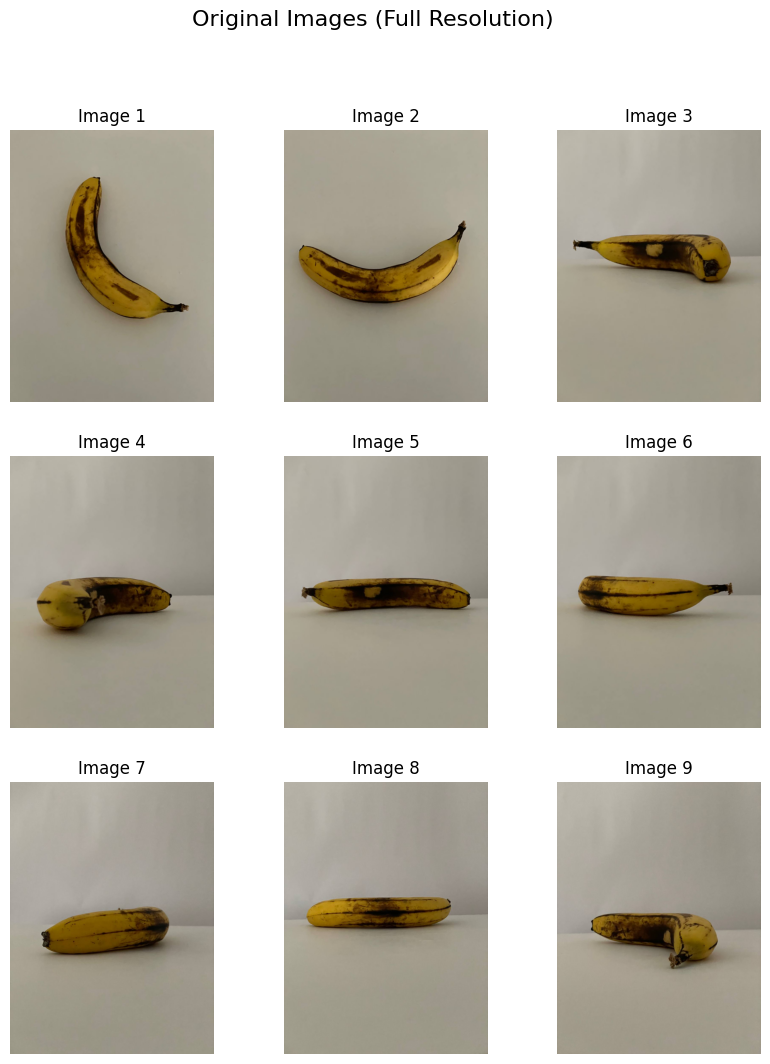

In [ ]:
# 3.8 GRID OF ORIGINAL IMAGES (960×1280) from my dataset

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

class_folder = "/content/drive/MyDrive/banana_dataset/dataset/train/overripe"

# Take the first 9 images from the folder
image_files = os.listdir(class_folder)[:9]

# create a 3x3 grid
plt.figure(figsize=(10, 12))

for i, file_name in enumerate(image_files):
    file_path = os.path.join(class_folder, file_name)

    img = mpimg.imread(file_path)  # view the image at its original size

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image {i+1}")

plt.suptitle("Original Images (Full Resolution)", fontsize=16)
plt.show()


# Stage 2: Creating the CNN architecture

## Step 4: Defining the model layers
 - Objective: to construct the architecture of a convolutional neural network by defining the sequence of layers that will extract features from images and classify bananas into 3 classes (unripe, ripe, overripe):
    - determine which layers the CNN requires
    - Select their order
    - Specify the number of filters
    - Select activation functions
    - Prepare the model for compilation and training
    - Ensure the architecture is clear, logical and well-founded (for the dissertation)

In [ ]:
# 4.1 Creating an empty model

model = tf.keras.Sequential() # model - is a variable, a BOX (empty), into which we will add layers one by one
                              # Sequential() - is a model in which layers follow strictly one after the other: layer 1 -> layer 2 -> layer 3 -> layer 4 -> ...

# This allows us to control the model’s logic:
# We can:
# add
# change
# delete
# rearrange
# test different models

# IT’S LIKE BUILDING A HOUSE FROM BRICKS: first the foundations -> walls -> windows -> roof


In [ ]:
# 4.2 Adding an augmentation layer to the model

# Objective:
# to incorporate augmentation into the CNN architecture so that the model automatically receives different image variations each time and learns more robustly

model.add(data_augmentation)

# model.add() – adds a new layer to the model. We place the first layer inside the BOX
# data_augmentation – this is the Sequential model we created earlier


In [ ]:
# It will convert pixels ranging from 0 to 255 into numbers ranging from 0.0 to 1.0
model.add(layers.Rescaling(1./255))

In [ ]:
# 4.3 Adding the FIRST convolutional layer – Conv2D – the neural network’s ‘main eye’

# this is the layer that will teach the model to ‘see’:
# the edges of the banana
# textures
# spots
# shapes
# the differences between unripe, ripe and overripe

model.add(layers.Conv2D(
  filters=32,                                # number of filters = number of mini-lenses in the model
  kernel_size=(3,3),                        # the size of the window (magnifying glass) through which the model views the image (3x3 – a small window; the smaller the window, the better the detail)
  activation='relu',                        # ReLU trains the model to identify IMPORTANT features, discarding all the unnecessary ones (result: faster, more stable, more accurate)
  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)    # 224x224 image, 3 channels (RGB)
))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 4.4 The essential layer in a CNN architecture - MaxPooling2D -> is the ‘brain’

# Objective:
# to reduce the size of the feature map and retain only the most important features

# This helps to:
# reduce the number of parameters
# speed up training
# reduce overfitting
# make features clearer
# takes small squares of the image (2x2) and keeps the HIGHEST VALUE in each square

# Max -> maximum value
# Pooling -> pooling

model.add(layers.MaxPooling2D(pool_size=(2,2)))             # reduces the feature maps by half (from 112x112 to 56x56)


# WHY IS THIS NECESSARY?
# Because the image from Conv2D becomes VERY DETAILED
# but we don’t need every single pixel – we only need the key features


In [ ]:
# 4.5 Adding a second Conv2D + MaxPooling2D block

# Why do we need a second block?

# The first block teaches the model to recognise SIMPLE features: lines, edges, basic shapes

# The second block teaches the model to recognise MORE COMPLEX features:
# the curve of a banana
# dark spots indicating ripeness
# colour transitions
# the texture of the skin

# !!!CNN works on the principle: simple layer -> more complex -> even more complex -> final decision

model.add(layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D(pool_size=(2,2)))

# Why Conv2D(filters=64) rather than the first layer (32):
# the deeper into the network -> the more complex the features
# more filters -> more opportunities to detect details of a banana’s ripeness
# THIS IS THE CNN STANDARD: 32 -> 64 -> 128 -> ...

# MaxPooling2D reduces the size again
# reduces the feature map by half again: 56x56 -> 28x28 (approximately)
# makes computations easier -> reduces noise -> retains what’s important


In [ ]:
# 4.6 Adding a THIRD Conv2D + MaxPooling2D block (the most powerful one)

# This block:
# completes feature extraction
# makes the model sufficiently robust
# ensures high-quality classification

model.add(layers.Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu'
))

model.add(layers.MaxPooling2D(pool_size=(2,2)))

# Conv2D(filters=128) is the most powerful convolutional layer in our basic CNN
# it learns to recognise:
# subtle patterns
# the distribution of dark areas
# the degree of darkness
# highly complex combinations of textures
# THIS LAYER MAKES THE MODEL ‘SMART’


## Step 5: Final layers

In [ ]:
# 5.1 Flatten (converting the feature map into a vector)

# Objective:
# to convert 3D feature maps (e.g. 28x28x128) into a single long vector, which can then be fed into Dense layers

model.add(layers.Flatten())

# Flatten layer:
# - converts a 3D layer in a network into a one-dimensional vector corresponding to the input data of a fully connected layer for classification
# Let’s imagine we have a Rubik’s cube (3D data). The Flatten layer ‘unfolds’ this cube into a single long strip (a one-dimensional vector), preserving all values in order.

# Takes a large 3D structure (Conv2D + MaxPooling layers):
# Example: 28 x 28 x 128

# flattens it into a single long row:
# example: [1, 0.5, 0.12, 0.9, 0.56, ...] <- a single vector (the final Dense layers require a VECTOR, not a tensor)


In [ ]:
# 5.2 Dense layer (the decision-making brain)

# Objective:
# To add a fully connected layer that combines features and learns to draw conclusions

# Combines all features
# Makes a decision
# Determines which class the banana belongs to (unripe, ripe, overripe)

model.add(layers.Dense(128, activation='relu'))

# Dense(128) - a layer consisting of 128 neurons

# Each neuron:
# receives all features
# analyses combinations
# learns to make a decision

# 128:
# this is a standard, robust value
# suitable for a medium-sized CNN
# trains well
# not too small and not too large

# activation=“relu”
# ReLU helps:
# to train faster
# to capture important features
# to avoid gradient issues

In [ ]:
# 5.3 Dropout (overfitting prevention)

# Dropout is a layer that RANDOMLY DISABLES SOME OF THE NEURONS to prevent the model from memorising the data

model.add(layers.Dropout(0.5, seed=seed))

# Dropout(0.5) means:
# during training, 50% (half) of the neurons are randomly deactivated

# Why?
# the model will not memorise specific images
# it will learn to work with features
# overfitting will be reduced
# the final accuracy on the test set will improve

In [ ]:
# 5.4 Adding a Softmax output layer (3 classes)

# Objective:
# to convert the features into three probabilities, based on which the model determines which class the banana belongs to

# OUTPUT LAYER = "FINAL DECISION"

model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

# NUM_CLASSES = 3 (Dense(3))
#  3 neurons = 3 classes (probability: unripe, ripe, overripe)

# activation=“softmax”:
# this is the mechanism for making a final, weighted decision
# instead of simply outputting three numbers [5, 92, 3], it converts them into probability percentages: 5%, 92%, 3%


In [ ]:
# VISUALISATION - MODEL DIAGRAM (CNN ARCHITECTURE)

!pip install pydot
!apt-get install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


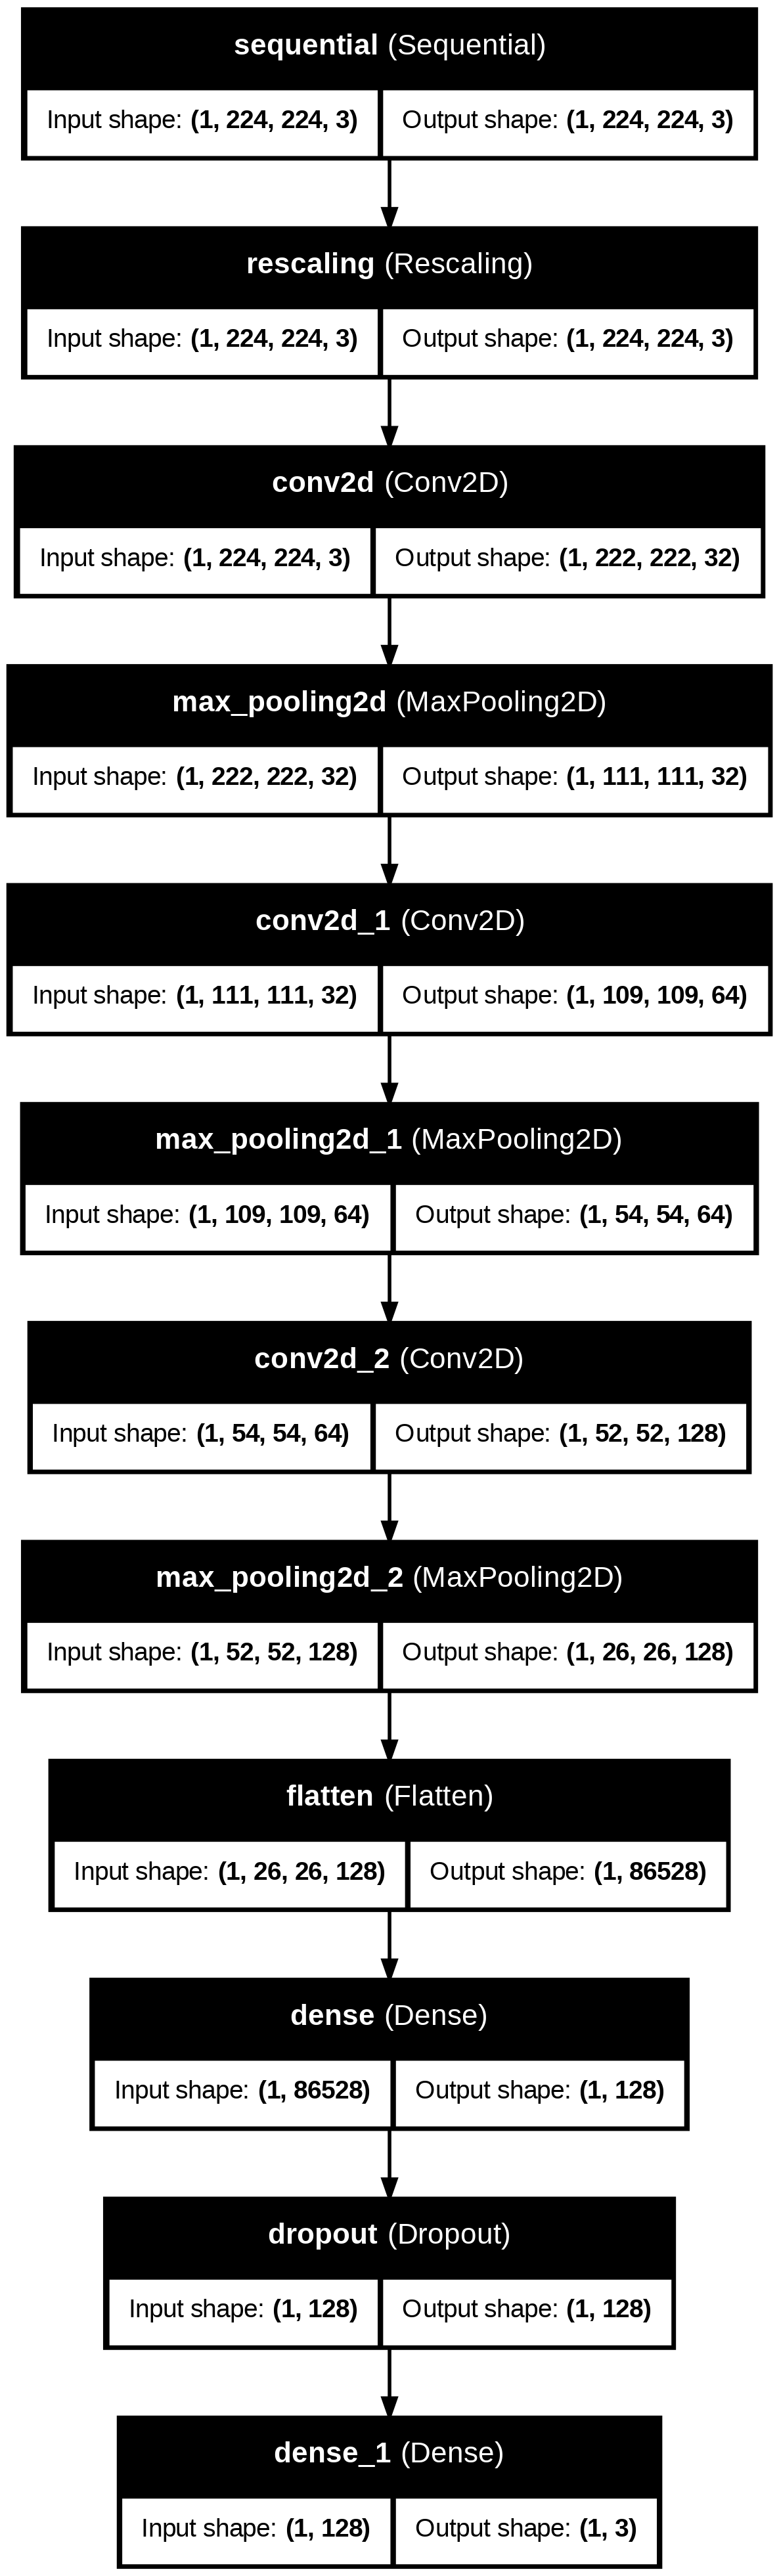

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model,
           to_file='cnn_architecture.png',
           show_shapes=True,                # show layer dimensions
           show_layer_names=True)           # show layer names

In [ ]:
dummy_input = np.zeros((1, 224, 224, 3))
model(dummy_input)

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[0.33329484, 0.34218255, 0.32452264]], dtype=float32)>

# Step 3: Training the model

## Step 6: Compiling the model
 - Objective: to configure the model for training by specifying how it will measure error, how it will adjust its weights, and what criteria we will use to evaluate its performance.
   -  select an optimiser to correct the model’s errors
   - select a loss function to measure how much the model is in error
   - select a metric to track the quality of training (accuracy)
   - prepare the model to start training (model.fit())

 Without compilation:
 - the model does not know how to learn
 - it does not know what is "correct" or "incorrect"
 - training is simply impossible

In [ ]:
# 6.1 Compiling the model

# – this is like setting the rules of the game before the model starts training

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),   # adam - the best optimiser for CNNs, automatically selects the learning rate
    loss=tf.keras.losses.CategoricalCrossentropy(),            # Loss function for multi-class tasks (0, 1, 2)
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
        ]                                       # accuracy - shows the percentage of correctly classified images
)


In [ ]:
# 6.2 SUMMARY - model.summary()

# Goal:
# to obtain summary information about the model (architecture, layers and number of parameters) to ensure that the structure has been assembled correctly and is ready for training

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 52, 52, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 26, 26, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 3)                 │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6.2 VIZUALIZATION

import pandas as pd

layers_data = []

for i, layer in enumerate(model.layers, 1):
    try:
        output_shape = str(layer.output.shape)
    except:
        output_shape = "N/A"

    layer_info = {
        "№": i,
        "Layer Name": layer.name,
        "Output Shape": output_shape,
        "Param #": layer.count_params()
    }
    layers_data.append(layer_info)

summary_table = pd.DataFrame(layers_data)
summary_table


,№,Layer Name,Output Shape,Param #
0,1,sequential,"(1, 224, 224, 3)",0
1,2,rescaling,"(1, 224, 224, 3)",0
2,3,conv2d,"(1, 222, 222, 32)",896
3,4,max_pooling2d,"(1, 111, 111, 32)",0
4,5,conv2d_1,"(1, 109, 109, 64)",18496
5,6,max_pooling2d_1,"(1, 54, 54, 64)",0
6,7,conv2d_2,"(1, 52, 52, 128)",73856
7,8,max_pooling2d_2,"(1, 26, 26, 128)",0
8,9,flatten,"(1, 86528)",0
9,10,dense,"(1, 128)",11075712


## Step 7: Training the CNN model
 - Goal: to train the model on the training data and test its performance on the validation data. Obtain accuracy and loss metrics by epoch to assess how well the model is learning

In [ ]:
# 7.1. Calculating class weights (class_weight)

# Number of images for each class in train_ds
counts = {
    0: 4299,    # overripe
    1: 1815,   # ripe
    2: 620    # unripe
}

N = sum(counts.values())   # total number of images
K = len(counts)            # number of classes

class_weights = {}

for cls, n_i in counts.items():
    class_weights[cls] = N / (K * n_i)

print("Class weights:", class_weights)


Class weights: {0: 0.5221369310692409, 1: 1.236730945821855, 2: 3.620430107526882}


In [ ]:
# Early stopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',        # monitoring the error during validation
    patience=5,                # waiting for 5 epochs without improvement
    restore_best_weights=True  # return the best weights
)

In [ ]:
# 7.2 Training the model (model.fit() - starts the training process)

history = model.fit(          # history - saves training results
    train_ds,                 # on which the model is trained
    validation_data=val_ds,   # on which the model is tested
    epochs=50,                # training passes to ensure the model learns effectively (we set it to 50, but EarlyStopping will most likely stop it at 15–20)
    class_weight=class_weights,
    callbacks=[early_stop]
)


Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1588s 8s/step - accuracy: 0.7891 - loss: 0.5375 - precision: 0.8382 - recall: 0.7363 - val_accuracy: 0.8942 - val_loss: 0.2368 - val_precision: 0.8942 - val_recall: 0.8942
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 101s 479ms/step - accuracy: 0.8952 - loss: 0.2601 - precision: 0.8965 - recall: 0.8940 - val_accuracy: 0.8499 - val_loss: 0.3496 - val_precision: 0.8503 - val_recall: 0.8499
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 94s 444ms/step - accuracy: 0.8846 - loss: 0.2794 - precision: 0.8864 - recall: 0.8825 - val_accuracy: 0.9195 - val_loss: 0.1711 - val_precision: 0.9195 - val_recall: 0.9195
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 137s 421ms/step - accuracy: 0.9015 - loss: 0.2251 - precision: 0.9021 - recall: 0.8999 - val_accuracy: 0.9562 - val_loss: 0.1009 - val_precision: 0.9562 - val_recall: 0.9562
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 93s 439ms/step - accuracy: 0.9148 - loss: 0.2058 - precision: 0.9155 - recall: 0.9142 - val_accuracy: 0.897

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# 7.3 Classification report for validation set

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = [] # List for storing CORRECT answers
y_pred = [] # List for storing the model's PREDICTIONS

# We take each batch of images and labels from the validation set
for images, labels in val_ds:
    # 1. asking the model to predict the class for the current images
    preds = model.predict(images, verbose=0)

    # 2. adding the CORRECT answers to our list (converting [1,0,0] to the number 0, 1 or 2)
    y_true.extend(np.argmax(labels.numpy(), axis=1))

    # 3. adding the model’s PREDICTIONS to our list (selecting the most likely class)
    y_pred.extend(np.argmax(preds, axis=1))

# Converting lists into standard arrays of numbers
y_true = np.array(y_true)
y_pred = np.array(y_pred)


print(classification_report(
    y_true,
    y_pred,
    target_names=['overripe', 'ripe', 'unripe'] # We use the procedure from step 3.5
))

# 4. Final check using the built-in `evaluate` function
print("--- EVALUATE ---")
results = model.evaluate(val_ds)

# We print all the metrics we specified during compilation (Loss, Acc, Precision, Recall)
print(f"Validation Loss: {results[0]:.4f}")
print(f"Validation Accuracy: {results[1]:.4f}")
print(f"Validation Precision: {results[2]:.4f}")
print(f"Validation Recall: {results[3]:.4f}")

print("\n--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)


              precision    recall  f1-score   support

    overripe       0.98      0.99      0.98      1326
        ripe       0.90      0.91      0.91       315
      unripe       1.00      0.92      0.96       184

    accuracy                           0.97      1825
   macro avg       0.96      0.94      0.95      1825
weighted avg       0.97      0.97      0.97      1825

--- EVALUATE ---
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 308ms/step - accuracy: 0.9671 - loss: 0.0782 - precision: 0.9671 - recall: 0.9671
Validation Loss: 0.0782
Validation Accuracy: 0.9671
Validation Precision: 0.9671
Validation Recall: 0.9671

--- CONFUSION MATRIX ---
[[1309   17    0]
 [  28  287    0]
 [   0   15  169]]


1. Accuracy
This answers the question: "What percentage of all bananas did the model predict correctly?"
2. Precision (Accuracy of prediction for a specific class)
This answers the question: "If the model says that this banana is GREEN, how much can we trust it?"
3. Recall (Completeness / Precision)
This answers the question: "How many of all the actually green bananas was the model ABLE to find?"

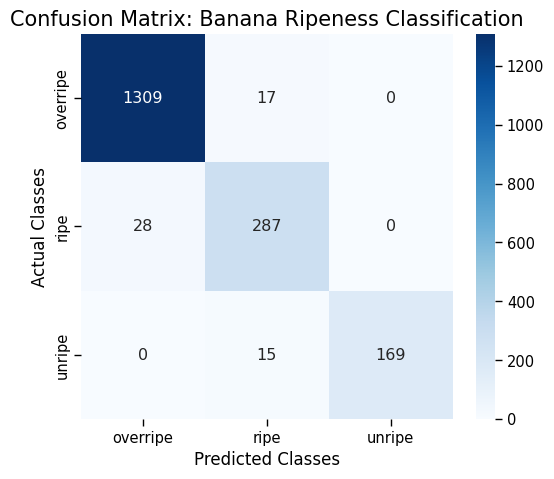

In [ ]:
# Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.set_context("paper", font_scale=1.2)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['overripe', 'ripe', 'unripe'],
    yticklabels=['overripe', 'ripe', 'unripe']
)

plt.title('Confusion Matrix: Banana Ripeness Classification', fontsize=15)
plt.ylabel('Actual Classes', fontsize=12)
plt.xlabel('Predicted Classes', fontsize=12)

plt.show()


# Stage 4: Evaluation and analysis of results

## Step 8: Evaluating the model on the test set
 - Goal: to check how well the trained model performs on completely new data that it has never seen before. This demonstrates the model’s true ability to generalise

In [ ]:
test_results = model.evaluate(test_ds)

print(f"\nTest Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall: {test_results[3]:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 259s 6s/step - accuracy: 0.9258 - loss: 0.2332 - precision: 0.9258 - recall: 0.9258

Test Loss: 0.2332
Test Accuracy: 0.9258
Test Precision: 0.9258
Test Recall: 0.9258


## Step 9: Detailed classification metrics (Classification Report + Confusion Matrix)

In [ ]:
# 9.1 Obtaining predictions on the test set

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)

    true_classes = np.argmax(labels, axis=1)
    pred_classes = np.argmax(preds, axis=1)

    y_true.extend(true_classes)
    y_pred.extend(pred_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━

In [ ]:
# 9.2 Classification Report

# accuracy
# precision
# recall
# f1-score
# macro avg
# weighted avg

class_names = ['overripe', 'ripe', 'unripe']

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

print(cm)

              precision    recall  f1-score   support

    overripe       0.99      0.91      0.95      1010
        ripe       0.69      0.93      0.79       211
      unripe       1.00      0.99      1.00       180

    accuracy                           0.93      1401
   macro avg       0.89      0.95      0.91      1401
weighted avg       0.94      0.93      0.93      1401

[[921  89   0]
 [ 14 197   0]
 [  0   1 179]]


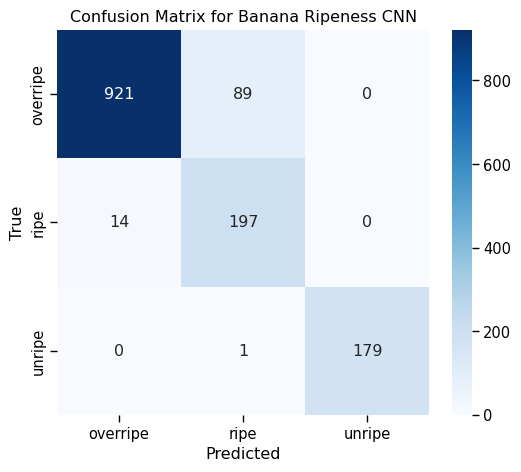

In [ ]:
# 9.3 Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

correct_names = ['overripe', 'ripe', 'unripe']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=correct_names,
            yticklabels=correct_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Banana Ripeness CNN")
plt.show()

## Step 10: Visualising the CNN training
 We plot two graphs:
  - Accuracy (train vs val)
  - Loss (train vs val)

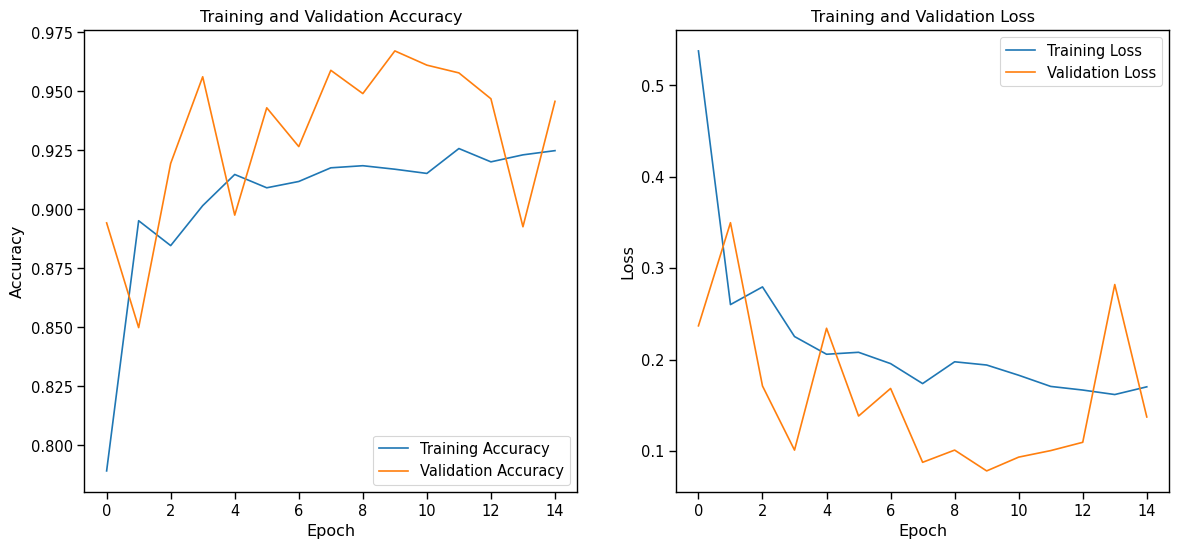

In [ ]:
import matplotlib.pyplot as plt

# История обучения (из history.history)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))

# ---- ACCURACY ----
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# ---- LOSS ----
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

# Testing on a new image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


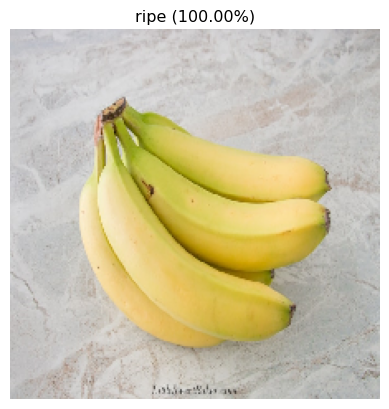

This banana is most likely: ripe


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = '/content/banana-ripe.jpg'

img = image.load_img(img_path, target_size=(224, 224))

img_array = image.img_to_array(img)


img_array = np.expand_dims(img_array, axis=0)


predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

class_names = ['overripe', 'ripe', 'unripe']
result_class = class_names[np.argmax(predictions)]
confidence = 100 * np.max(predictions)

plt.imshow(img)
plt.title(f"{result_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"This banana is most likely: {result_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


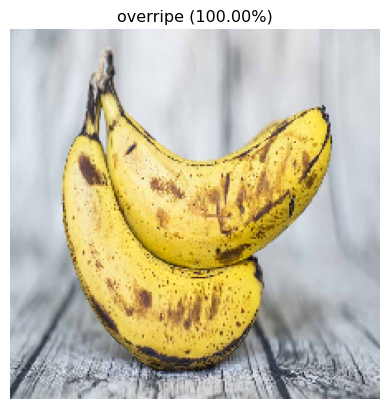

This banana is most likely:overripe


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = '/content/overripe-bananas.jpg'

img = image.load_img(img_path, target_size=(224, 224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

class_names = ['overripe', 'ripe', 'unripe']
result_class = class_names[np.argmax(predictions)]
confidence = 100 * np.max(predictions)

plt.imshow(img)
plt.title(f"{result_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"This banana is most likely:{result_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


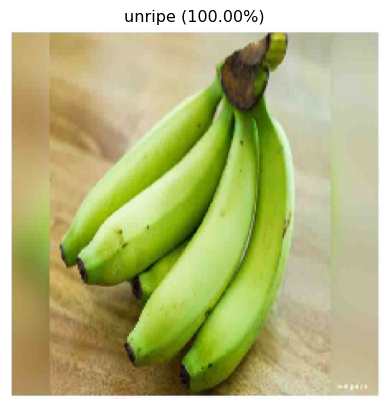

This banana is most likely: unripe


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = '/content/unripe-banana.jpg'

img = image.load_img(img_path, target_size=(224, 224))

img_array = image.img_to_array(img)


img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

class_names = ['overripe', 'ripe', 'unripe']
result_class = class_names[np.argmax(predictions)]
confidence = 100 * np.max(predictions)

plt.imshow(img)
plt.title(f"{result_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"This banana is most likely: {result_class}")